In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
# --- 1. Load Data ---
url = "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
print(f"Loading data from {url}...")
df = pd.read_csv(url)

# Display first few rows
print("Data Sample:")
display(df.head())

Loading data from https://storage.googleapis.com/download.tensorflow.org/data/heart.csv...
Data Sample:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [11]:
# --- 2. Data Preprocessing ---

# A. Handle Categorical Columns
# Mapping 'thal' column: string -> integer
df["thal"] = df["thal"].map({"normal": 0, "fixed": 1, "reversible": 2})

# B. Separate Target and Features
X = df.drop(columns=["target"])
y = df["target"]

# Save feature names for later use (plotting, etc.)
feature_names = X.columns.tolist()

# C. Imputation
# Using SimpleImputer with set_output="pandas" to keep feature names
imputer = SimpleImputer(strategy="most_frequent")
imputer.set_output(transform="pandas")
X_imputed = imputer.fit_transform(X)

# D. Scaling
# Standardize features (Mean=0, Std=1)
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_scaled = scaler.fit_transform(X_imputed)

# E. Split Data
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nFeatures processed: {feature_names}")
print(f"Training set shape: {X_tr.shape}")
print(f"Test set shape: {X_te.shape}")


Features processed: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Training set shape: (227, 13)
Test set shape: (76, 13)


In [12]:
# --- 3. Prediction Helper Function ---

def predict_sample(model, raw_sample_list, imputer, scaler, feature_names):
    """
    Takes a raw sample list, processes it (encoding -> imputing -> scaling),
    and returns the prediction.
    """
    # Create DataFrame to match training columns
    sample_df = pd.DataFrame([raw_sample_list], columns=feature_names)
    
    # Handle 'thal' encoding if it's passed as a string
    if sample_df['thal'].dtype == 'object' or isinstance(sample_df.iloc[0]['thal'], str):
         # Map using the same dictionary as training
         sample_df["thal"] = sample_df["thal"].map({"normal": 0, "fixed": 1, "reversible": 2})
            
    # Impute (using the fitted imputer)
    sample_imp = imputer.transform(sample_df)
    
    # Scale (using the fitted scaler)
    sample_scaled = scaler.transform(sample_imp)
    
    # Predict
    pred = model.predict(sample_scaled)[0]
    
    # Decode Prediction
    result = "Heart Disease" if pred == 1 else "No Heart Disease"
    
    # Print result
    print(f"\nSample Prediction using {model.__class__.__name__}: {result}")
    return result

# Define the sample data (from user request)
# Age, Sex, CP, Trestbps, Chol, FBS, RestECG, Thalach, Exang, Oldpeak, Slope, CA, Thal
raw_sample = [57, 1, 2, 140, 241, 0, 1, 123, 1, 0.2, 1, 0, "reversible"]
print("Sample data defined.")

Sample data defined.


Gaussian Naive Bayes Performance:
Accuracy: 0.9079
------------------------------
              precision    recall  f1-score   support

           0       0.90      0.98      0.94        55
           1       0.94      0.71      0.81        21

    accuracy                           0.91        76
   macro avg       0.92      0.85      0.87        76
weighted avg       0.91      0.91      0.90        76



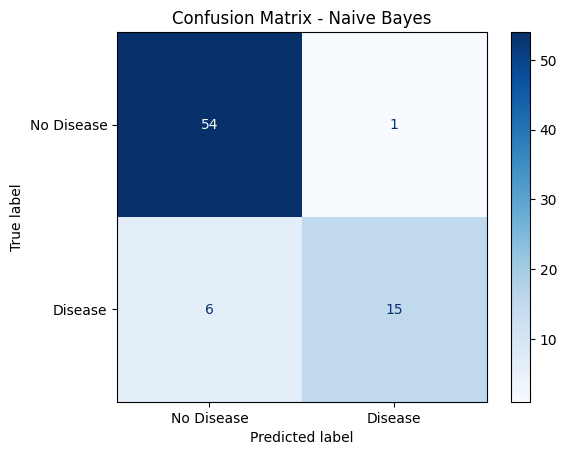


Sample Prediction using GaussianNB: No Heart Disease


'No Heart Disease'

In [13]:
# --- 4. Model: Gaussian Naive Bayes ---

# Initialize
gnb = GaussianNB()

# Train
gnb.fit(X_tr, y_tr)

# Predict
y_pred_gnb = gnb.predict(X_te)

# Evaluate
print("Gaussian Naive Bayes Performance:")
print(f"Accuracy: {accuracy_score(y_te, y_pred_gnb):.4f}")
print("-" * 30)
print(classification_report(y_te, y_pred_gnb))

# Confusion Matrix Support
cm = confusion_matrix(y_te, y_pred_gnb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

# Sample Prediction
predict_sample(gnb, raw_sample, imputer, scaler, feature_names)

Decision Tree Performance:
Accuracy: 0.8421
------------------------------
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        55
           1       0.80      0.57      0.67        21

    accuracy                           0.84        76
   macro avg       0.83      0.76      0.78        76
weighted avg       0.84      0.84      0.83        76



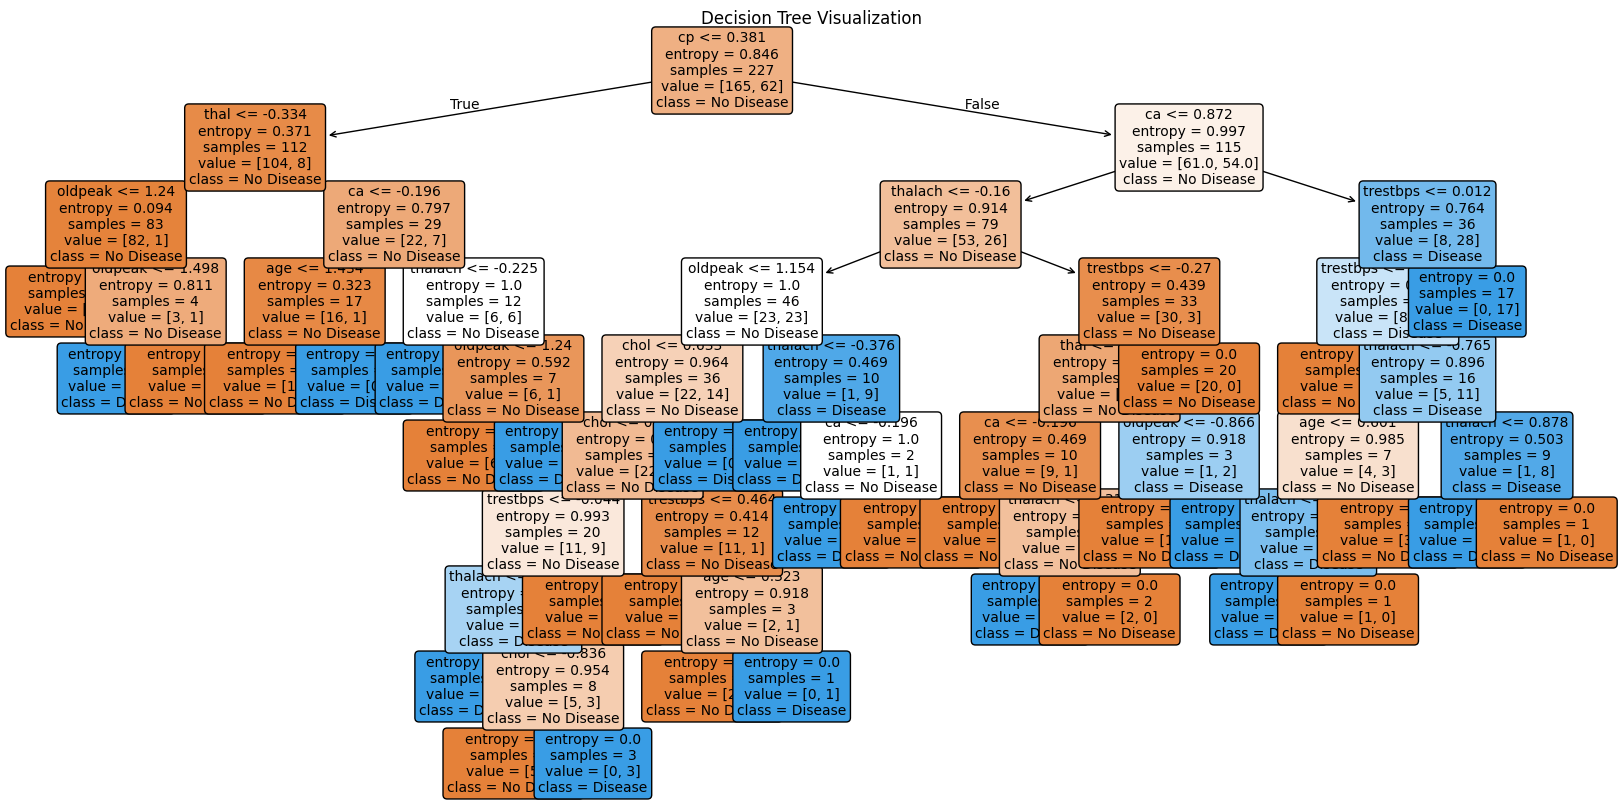


Sample Prediction using DecisionTreeClassifier: No Heart Disease


'No Heart Disease'

In [14]:
# --- 5. Model: Decision Tree ---

# Initialize (using entropy as requested)
dt = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=None)

# Train
dt.fit(X_tr, y_tr)

# Predict
y_pred_dt = dt.predict(X_te)

# Evaluate
print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_te, y_pred_dt):.4f}")
print("-" * 30)
print(classification_report(y_te, y_pred_dt))

# Visualize Tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt, 
    feature_names=feature_names, 
    class_names=["No Disease", "Disease"], 
    filled=True, 
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()

# Sample Prediction
predict_sample(dt, raw_sample, imputer, scaler, feature_names)

In [15]:
# --- 6. Model: MLP Classifier (Neural Network) ---

# Initialize
# Using hidden layer size (16,8) for better capacity than single layer, inputs are standardized so convergence is faster.
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', max_iter=1000, random_state=42)

# Train
mlp.fit(X_tr, y_tr)

# Predict
y_pred_mlp = mlp.predict(X_te)

# Evaluate
print("MLP Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_te, y_pred_mlp):.4f}")
print("-" * 30)
print(classification_report(y_te, y_pred_mlp))

# Sample Prediction
predict_sample(mlp, raw_sample, imputer, scaler, feature_names)

MLP Classifier Performance:
Accuracy: 0.8553
------------------------------
              precision    recall  f1-score   support

           0       0.84      0.98      0.91        55
           1       0.92      0.52      0.67        21

    accuracy                           0.86        76
   macro avg       0.88      0.75      0.79        76
weighted avg       0.86      0.86      0.84        76


Sample Prediction using MLPClassifier: No Heart Disease


'No Heart Disease'

Final Comparison:
            Model  Accuracy
0     Naive Bayes  0.907895
1   Decision Tree  0.842105
2  MLP Classifier  0.855263


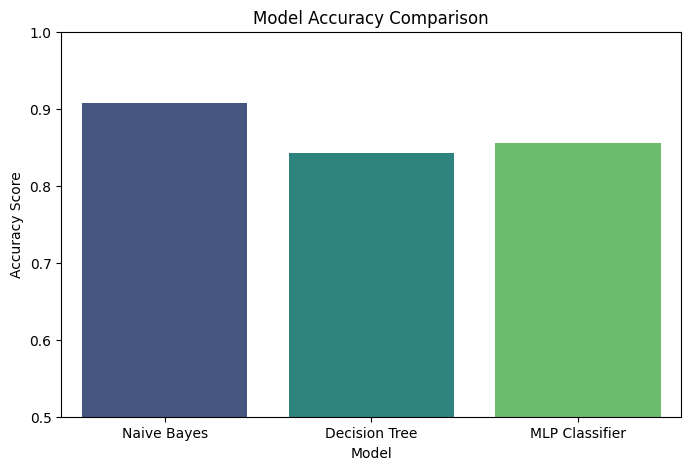

In [16]:
# --- 7. Model Comparison ---

results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Decision Tree', 'MLP Classifier'],
    'Accuracy': [
        accuracy_score(y_te, y_pred_gnb),
        accuracy_score(y_te, y_pred_dt),
        accuracy_score(y_te, y_pred_mlp)
    ]
})

print("Final Comparison:")
print(results)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis', hue='Model', legend=False)
plt.title("Model Accuracy Comparison")
plt.ylim(0.5, 1.0) # Zoom in to relevant range
plt.ylabel("Accuracy Score")
plt.show()